In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc

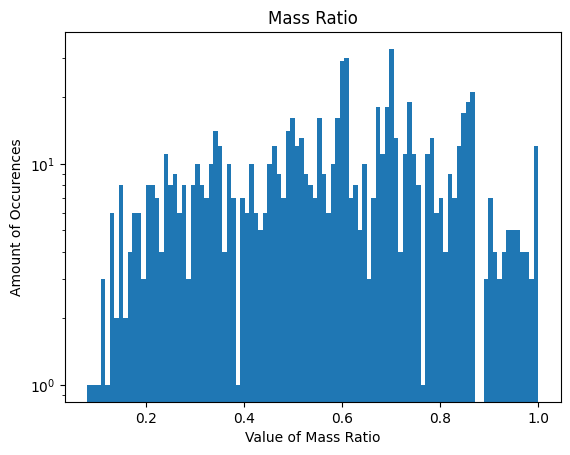

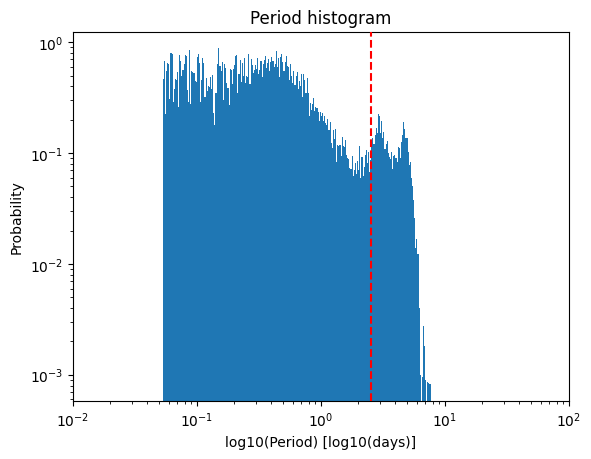

In [ ]:
df = pd.read_csv(r'DATA/RAW/reduced_raw_data.csv')
eccentricity = df["e"]
mass_ratio = df["q"]
period = df["period"]
semi_major_ax = df["a"]
id = df["system_id"]

plt.hist(mass_ratio, log=True, bins=100)
plt.xlabel('Value of Mass Ratio')
plt.ylabel('Amount of Occurences')
plt.title('Mass Ratio')
plt.show()


bins = np.logspace(np.log10(period.min()),
                   np.log10(period.max()),
                   1000)
plt.hist(np.log10(period), log=True, bins=bins, density=True)
#plt.axvline(365, color = 'red', linestyle='dashed',zorder = 45)
plt.xlabel('log10(Period) [log10(days)]')
plt.ylabel('Probability')
plt.title('Period histogram')
plt.xlim(10**-2,10**2)
plt.xscale('log')
plt.axvline(np.log10(365), color = 'red', linestyle = 'dashed', zorder = 45)
plt.show()

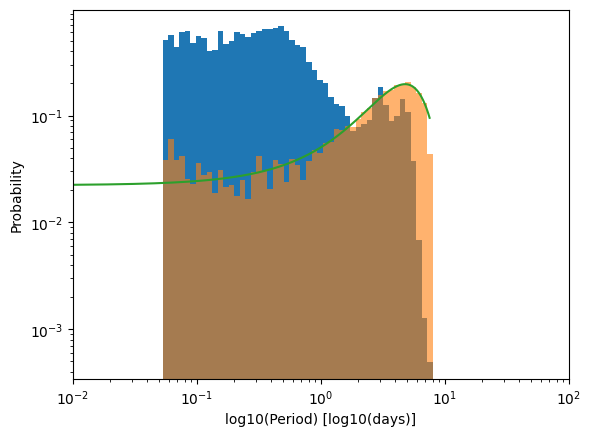

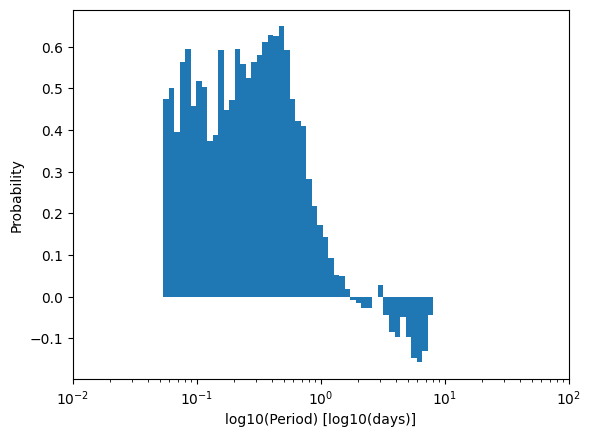

In [121]:
#Bias in Mass ratio, for low ratios. One star is just that much heavier
#Duquennoy & Mayor (1991) https://academic.oup.com/mnras/article/417/3/1684/1084726?login=true
def log_per_dist(lP):
    mu = 4.8
    sig = 2.3
    return 1/(sig*np.sqrt(2*np.pi))*np.exp(-(lP-mu)**2/(2*sig**2))

N=200
bins = np.logspace(np.log10(period.min()),
                   np.log10(period.max()),
                   N)
Pers = np.linspace(np.log10(period.min()), np.log10(period.max()),len(period))
hist_dat, bin_edges, patches = plt.hist(np.log10(period), log=True, bins=bins, density=True)

bin_centers = (bin_edges[:-1]+bin_edges[1:])/2

# Compute probabilities
p = log_per_dist(Pers)

# Normalize so probabilities sum to 1
p = p / p.sum()

# Sample x according to the function
samples = np.random.choice(Pers, size=len(period), p=p)

# Plot
dist_dat, dist_edges, dist_patch = plt.hist(samples, bins=bins, density=True, alpha=0.6)

# Plot normalized function
plt.plot(Pers, p / (Pers[1]-Pers[0]))
plt.xscale('log')
plt.xlim(10**-2,10**2)
plt.title('')
plt.xlabel('log10(Period) [log10(days)]')
plt.ylabel('Probability')
plt.show()

hist_diff = hist_dat - dist_dat
plt.bar(bin_centers, hist_diff, width=np.diff(bin_edges), align='center')
plt.xscale('log')
plt.xlim(10**-2,10**2)
plt.title('')
plt.xlabel('log10(Period) [log10(days)]')
plt.ylabel('Probability')
plt.show()